In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from tensorflow import keras

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
from keras.layers import Dense, Input, Flatten
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

In [5]:
data= pd.read_csv("ecommerce_customer_churn_dataset.csv")

In [6]:
data

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [8]:
data.dropna(inplace=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17983 entries, 0 to 49994
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            17983 non-null  float64
 1   Gender                         17983 non-null  object 
 2   Country                        17983 non-null  object 
 3   City                           17983 non-null  object 
 4   Membership_Years               17983 non-null  float64
 5   Login_Frequency                17983 non-null  float64
 6   Session_Duration_Avg           17983 non-null  float64
 7   Pages_Per_Session              17983 non-null  float64
 8   Cart_Abandonment_Rate          17983 non-null  float64
 9   Wishlist_Items                 17983 non-null  float64
 10  Total_Purchases                17983 non-null  float64
 11  Average_Order_Value            17983 non-null  float64
 12  Days_Since_Last_Purchase       17983 non-null  floa

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [11]:
onehot= OneHotEncoder(handle_unknown="ignore")
scaler= StandardScaler()

In [12]:
x= data.drop(columns=["Churned", "City", "Country", "Gender", "Signup_Quarter"])
y= data["Churned"].copy()

In [13]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train.shape, y_train.shape

((14386, 20), (14386,))

In [15]:
from keras.models import Sequential

In [16]:
model= Sequential([
    Input(shape=(20,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1, activation="sigmoid")  
])

In [17]:
model.compile(
    optimizer="Adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=1,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [19]:
x_train_arr= scaler.fit_transform(x_train)
x_test_arr= scaler.transform(x_test)

In [20]:
history= model.fit(x_test_arr, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=callback)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6708 - loss: 0.6439 - val_accuracy: 0.7403 - val_loss: 0.5995
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7313 - loss: 0.6090 - val_accuracy: 0.7403 - val_loss: 0.5888
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7313 - loss: 0.5976 - val_accuracy: 0.7403 - val_loss: 0.5853
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7313 - loss: 0.5910 - val_accuracy: 0.7403 - val_loss: 0.5824
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7313 - loss: 0.5865 - val_accuracy: 0.7403 - val_loss: 0.5819
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7313 - loss: 0.5842 - val_accuracy: 0.7403 - val_loss: 0.5819
Epoch 6: early stopping


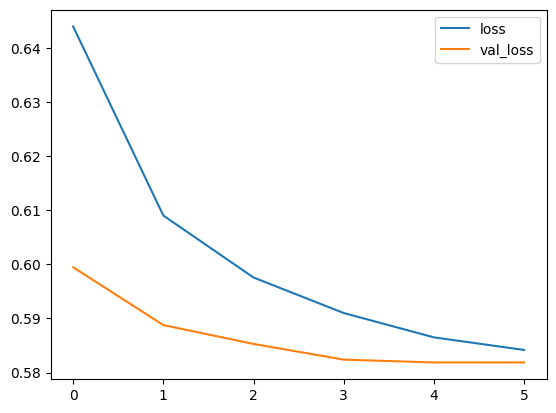

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="loss"),
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()